In [1]:
import Pkg;
Pkg.activate(@__DIR__);
Pkg.instantiate();

  Activating project at `~/optimal-control/code/lec9`


In [2]:
using LinearAlgebra
using SparseArrays
using ControlSystems
using ForwardDiff
using OSQP
using LaTeXStrings
import SymPy
using PyPlot

using JupyterFormatter
enable_autoformat()

plt.rc("text", usetex = true)
plt.rc("font", family = "Times New Roman")
plt.rc("text.latex", preamble = "\\usepackage{{amsmath}}")

In [3]:
# model parameters
g = 9.81  # m/s^2
m = 1.0  # kg
l = 0.3  # meters
J = 0.2 * m * l * l

# thrust limits
u_min = 0.2 * m * g * ones(2)
u_max = 0.6 * m * g * ones(2)

# time step (20Hz)
N_h = 20  # horizon
h = 1 / N_h

# fixed point
x_hover = zeros(6)
u_hover = 0.5 * m * g * ones(2);

In [4]:
# planar quadrotor dynamics
function quad_dynamics(x, u)
    # x = [x, y, theta, dot_x, dot_y, dot_theta]
    # u = [u1, u2]
    theta = x[3]
    ddot_x = -(1 / m) * (u[1] + u[2]) * sin(theta)
    ddot_y = (1 / m) * (u[1] + u[2]) * cos(theta) - g
    ddot_theta = (1 / J) * (l / 2) * (u[2] - u[1])
    return [x[4:6]; ddot_x; ddot_y; ddot_theta]
end

quad_dynamics (generic function with 1 method)

In [5]:
# Linearized dynamics for hovering. Method 1: RK4
function quad_dynamics_rk4(x, u)
    # RK4 integration with ZOH on u
    f1 = quad_dynamics(x, u)
    f2 = quad_dynamics(x + 0.5 * h * f1, u)
    f3 = quad_dynamics(x + 0.5 * h * f2, u)
    f4 = quad_dynamics(x + h * f3, u)
    return x + (h / 6.0) * (f1 + 2 * f2 + 2 * f3 + f4)
end

A = ForwardDiff.jacobian(x -> quad_dynamics_rk4(x, u_hover), x_hover);
B = ForwardDiff.jacobian(u -> quad_dynamics_rk4(x_hover, u), u_hover);
# display(quad_dynamics_rk4(x_hover, u_hover));  # check the fixed point (equilibrium)
# display(A);
# display(B);

\begin{align*}
    u_1 = u_2 = \frac{1}{2} mg,  \ \theta = 0\text{ (Hover)} \\          
    \Rightarrow
    \begin{cases}
        \Delta \ddot x      & \approx \frac{\partial f_1(x,y,\theta,u)}{\partial u_1}|_{\text{Hover}} \Delta u_1 + \frac{\partial f_1(x,y,\theta,u)}{\partial u_2}|_{\text{Hover}}\Delta u_2 + \frac{\partial f_1(x,y,\theta,u)}{\partial \theta}|_{\text{Hover}}\Delta \theta  \\
                            & \approx\frac{1}{m}\left(-sin(\theta)|_{\text{Hover}}\Delta u_1-sin(\theta)|_{\text{Hover}}\Delta u_2 -(u_1+u_2)cos(\theta)|_{\text{Hover}}\Delta \theta\right)\approx-g \Delta \theta                                                                                      \\
        \Delta \ddot y      & \approx \frac{\partial f_2(x,y,\theta,u)}{\partial u_1}|_{\text{Hover}} \Delta u_1 + \frac{\partial f_2(x,y,\theta,u)}{\partial u_2}|_{\text{Hover}}\Delta u_2 + \frac{\partial f_2(x,y,\theta,u)}{\partial \theta}|_{\text{Hover}}\Delta \theta  \\
                            & \approx \frac{1}{m}\left(cos(\theta)|_{\text{Hover}}\Delta u_1+cos(\theta)|_{\text{Hover}}\Delta u_2 -(u_1+u_2)sin(\theta)|_{\text{Hover}}\Delta \theta\right)\approx \frac{1}{m} (\Delta u_1 + \Delta u_2)                                                                \\
        \Delta \ddot \theta & \approx \frac{1}{J} \frac{l}{2}(\Delta u_2 - \Delta u_1)
    \end{cases}                                       \\
\end{align*}

\begin{equation}
    \underset{\dot{x}}{\underbrace{\left[ \begin{array}{c}
        \Delta \dot{x}\\
        \Delta \dot{y}\\
        \Delta \dot{\theta}\\
        \Delta \ddot{x}\\
        \Delta \ddot{y}\\
        \Delta \ddot{\theta}\\
    \end{array} \right] }}=\underset{A}{\underbrace{\left[ \begin{matrix}
        0&		0&		0&		1&		0&		0\\
        0&		0&		0&		0&		1&		0\\
        0&		0&		0&		0&		0&		1\\
        0&		0&		-g&		0&		0&		0\\
        0&		0&		0&		0&		0&		0\\
        0&		0&		0&		0&		0&		0\\
    \end{matrix} \right] }}\underset{x}{\underbrace{\left[ \begin{array}{c}
        \Delta x\\
        \Delta y\\
        \Delta \theta\\
        \Delta \dot{x}\\
        \Delta \dot{y}\\
        \Delta \dot{\theta}\\
    \end{array} \right] }}+\underset{B}{\underbrace{\left[ \begin{matrix}
        0&		0\\
        0&		0\\
        0&		0\\
        0&		0\\
        \frac{1}{m}&		\frac{1}{m}\\
        -\frac{l}{2J}&		\frac{l}{2J}\\
    \end{matrix} \right] }}\underset{u}{\underbrace{\left[ \begin{array}{c}
        \Delta u_1\\
        \Delta u_2\\
    \end{array} \right] }}
\end{equation}

In [6]:
# Linearized dynamics for hovering. Method 2: Taylor series + matrix exponential
A_c = [0 0 0 1 0 0; 0 0 0 0 1 0; 0 0 0 0 0 1; 0 0 -g 0 0 0; 0 0 0 0 0 0; 0 0 0 0 0 0];
B_c = [0 0; 0 0; 0 0; 0 0; 1/m 1/m; -l/(2*J) l/(2*J)]
# derive discrete time system using matrix exponential
h_sym = SymPy.Sym("h")
D_sym = SymPy.exp([A_c B_c; zeros(size(B_c, 2), size(A_c, 1) + size(B_c, 2))] * h_sym)

D = SymPy.convert(Matrix{Float64}, D_sym.subs(h_sym, h))  # sparse matrix is sensitive to the type

A = D[1:size(A_c, 1), 1:size(A_c, 1)];
B = D[1:size(A_c, 1), size(A_c, 1)+1:end];
# display(A);
# display(B);

In [7]:
N_x = 6     # number of state
N_u = 2     # number of controls
T_final = 10.0 # final time
t_history = Array(0:h:T_final);
N_t = length(t_history);   # number of time steps

# cost weights
Q = sparse(1.0 * I(N_x));
R = sparse(0.01 * I(N_u));
Q_N = sparse(1.0 * I(N_x));

In [8]:
# cost function
function cost(x_history, u_history)
    cost = 0.5 * x_history[:, end]' * Q_N * x_history[:, end]
    for k = 1:(size(x_history, 2)-1)
        cost =
            cost +
            0.5 * x_history[:, k]' * Q * x_history[:, k] +
            0.5 * (u_history[k]'*R*u_history[k])[1]
    end
    return cost
end

cost (generic function with 1 method)

In [9]:
# LQR Hover Controller
P = are(Discrete, A, B, Array(Q), Array(R))  # not support sparse matrix
K = lqr(Discrete, A, B, Array(Q), Array(R))

function lqr_controller(x, K, x_ref)
    # delta_u = u_k - u_ref
    # ==> u_k = delta_u + u_ref = u_ref - K * delta_x = u_ref - K * (x_k - x_ref)
    return u_hover - K * (x - x_ref)
end

lqr_controller (generic function with 1 method)

In [41]:
# build QP matrices for OSQP
# https://osqp.org/docs/examples/setup-and-solve.html
S_u = kron(I(N_h), [I zeros(N_u, N_x)])  # matrix that picks out all u from decision variable
S_theta = kron(I(N_h), [0 0 0 0 1 0 0 0])  # matrix that picks out all theta from decision variable
H = blockdiag(R, kron(I(N_h - 1), blockdiag(Q, R)), sparse(P))  # MPC's terminal cost is LQR cost-to-go
# the problem might be to track a trajectory, so linear term in cost function is not zero
b = zeros((N_h) * (N_x + N_u))  # is updated each step in the next cell, since x1 varies
C = sparse(kron(I(N_h), [B -I(N_x)]))
for k = 1:N_h-1
    C[(k*N_x).+(1:N_x), (k*(N_u+N_x)-N_x).+(1:N_x)] .= A
end

#Dynamics + Thrust limit constraints
# D = [C; S_u]
# lb = [zeros(N_x * (N_h)); kron(ones(N_h), u_min - u_hover)]  # -Ax1 is updated in the next cell
# ub = [zeros(N_x * (N_h)); kron(ones(N_h), u_max - u_hover)]  # -Ax1 is updated in the next cell

# Dynamics + thrust limit + bound constraint on theta to keep the system within small-angle approximation
D = [C; S_u; S_theta]
lb = [zeros(N_x * N_h); kron(ones(N_h), u_min - u_hover); -0.2 * ones(N_h)]
ub = [zeros(N_x * N_h); kron(ones(N_h), u_max - u_hover); 0.2 * ones(N_h)]

prob = OSQP.Model()
OSQP.setup!(
    prob;
    P = H,
    q = b,
    A = D,
    l = lb,
    u = ub,
    verbose = false,
    eps_abs = 1e-8,
    eps_rel = 1e-8,
    polish = 1,
)


false

In [42]:
function mpc_controller(x, x_ref)
    # update lower and upper bound in QP
    lb[1:6] .= -A * x
    ub[1:6] .= -A * x

    # update linear term in QP    
    for k = 1:(N_h)
        b[(k*(N_x+N_u)-N_x).+(1:N_x)] .= -Q * x_ref
    end
    b[((N_h)*(N_x+N_u)-N_x).+(1:N_x)] .= -P * x_ref

    OSQP.update!(prob, q = b, l = lb, u = ub)

    #Solve QP
    results = OSQP.solve!(prob)
    delta_u = results.x[1:N_u]

    return u_hover + delta_u
end

mpc_controller (generic function with 1 method)

In [43]:
function closed_loop(x0, controller, N)
    # act as a simulator
    x_history = zeros(length(x0), N)
    u0 = controller(x0)
    u_history = zeros(length(u0), N - 1)
    u_history[:, 1] .= u0
    x_history[:, 1] .= x0
    for k = 1:(N-1)
        uk = controller(x_history[:, k])
        u_history[:, k] = max.(min.(u_max, uk), u_min) #enforce control limits
        x_history[:, k+1] .= quad_dynamics_rk4(x_history[:, k], u_history[:, k])
    end
    return x_history, u_history
end

closed_loop (generic function with 1 method)

In [44]:
x_ref = [0.0; 1.0; 0; 0; 0; 0]
x0 = [5.0; 2.0; 0.0; 0; 0; 0]
x_history1, u_history1 = closed_loop(x0, x -> lqr_controller(x, K, x_ref), N_t);
x_history2, u_history2 = closed_loop(x0, x -> mpc_controller(x, x_ref), N_t);

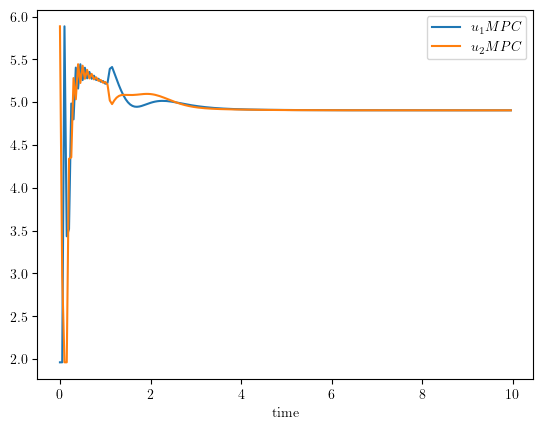

In [46]:
# plot(t_history, x_history1[1, :], label = "x LQR")
# plot(t_history, x_history2[1, :], label = "x MPC")
# plot(t_history, x_history1[2, :], label = "y LQR")
# plot(t_history, x_history2[2, :], label = "y MPC")
# plot(t_history, x_history1[3, :], label = L"\theta LQR")
# plot(t_history, x_history2[3, :], label = L"\theta MPC")
# plot(t_history[1:end-1], u_history1[1, :], label = L"u_1 LQR")
plot(t_history[1:end-1], u_history2[1, :], label = L"u_1 MPC")
# plot(t_history[1:end-1], u_history1[2, :], label = L"u_2 LQR")
plot(t_history[1:end-1], u_history2[2, :], label = L"u_2 MPC")
# ylim([-1, 2.5])
xlabel("time")
legend()
savefig("far_control_mpc.pdf")

In [47]:
#Set up visualization
using MeshCat
using RobotZoo: Quadrotor, PlanarQuadrotor
using CoordinateTransformations, Rotations, Colors, StaticArrays, RobotDynamics

function set_mesh!(
    vis,
    model::L;
    scaling = 1.0,
    color = colorant"black",
) where {L<:Union{Quadrotor,PlanarQuadrotor}}
    # urdf_folder = joinpath(@__DIR__, "..", "data", "meshes")
    urdf_folder = @__DIR__
    # if scaling != 1.0
    #     quad_scaling = 0.085 * scaling
    obj = joinpath(urdf_folder, "quadrotor_scaled.obj")
    if scaling != 1.0
        error("Scaling not implemented after switching to MeshCat 0.12")
    end
    robot_obj = MeshFileGeometry(obj)
    mat = MeshPhongMaterial(color = color)
    setobject!(vis["robot"]["geom"], robot_obj, mat)
    if hasfield(L, :ned)
        model.ned && settransform!(vis["robot"]["geom"], LinearMap(RotX(pi)))
    end
end

function visualize!(vis, model::PlanarQuadrotor, x::StaticVector)
    py, pz = x[1], x[2]
    θ = x[3]
    settransform!(vis["robot"], compose(Translation(0, py, pz), LinearMap(RotX(-θ))))
end

function visualize!(vis, model, tf::Real, X)
    fps = Int(round((length(X) - 1) / tf))
    anim = MeshCat.Animation(fps)
    for (k, x) in enumerate(X)
        atframe(anim, k) do
            x = X[k]
            visualize!(vis, model, SVector{6}(x))
        end
    end
    setanimation!(vis, anim)
end

visualize! (generic function with 2 methods)

In [44]:
vis = Visualizer()
model = PlanarQuadrotor()
set_mesh!(vis, model)
render(vis)

[ Info: Listening on: 127.0.0.1:8701, thread id: 1
┌ Info: MeshCat server started. You can open the visualizer by visiting the following URL in your browser:
└ http://127.0.0.1:8701


MeshCat.DisplayedVisualizer(MeshCat.CoreVisualizer(MeshCat.SceneTrees.SceneNode(nothing, nothing, Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}("meshcat" => MeshCat.SceneTrees.SceneNode(nothing, nothing, Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}("robot" => MeshCat.SceneTrees.SceneNode(nothing, nothing, Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}("geom" => MeshCat.SceneTrees.SceneNode(UInt8[0x83, 0xa6, 0x6f, 0x62, 0x6a, 0x65, 0x63, 0x74, 0x84, 0xaa  …  0x72, 0x6f, 0x62, 0x6f, 0x74, 0x2f, 0x67, 0x65, 0x6f, 0x6d], nothing, Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}()))))))), Set{HTTP.WebSockets.WebSocket}(), ip"127.0.0.1", 8701))

In [59]:
X1 = [SVector{6}(x) for x in eachcol(x_history1)];
X2 = [SVector{6}(x) for x in eachcol(x_history2)];

In [60]:
visualize!(vis, model, t_history[end], X1)

In [61]:
visualize!(vis, model, t_history[end], X2)